# 03 · The fundamental diagram — capacity is a fit, not a lane tag

Everything downstream (μ/C, D/C, QVDF) depends on **capacity C** and
**speed-at-capacity v_c**. We estimate them by fitting flow–density models
to real observations with a robust (Huber) loss — never by trusting map
attributes (a hard-won lesson: OSM said 2 lanes on a 5,136 veh/h roadway).

Data: the in-repo `fd_16models` benchmark input (real detector data).
The full 16-model tournament is reproduced in
[benchmarks/fd_16models](../benchmarks/fd_16models/index.html).

In [1]:
%matplotlib inline
# If cbi-plus is pip-installed this import just works; on a raw repo
# checkout we add the repo root to the path instead.
try:
    import cbi_pipeline
except ImportError:
    import sys
    from pathlib import Path
    sys.path.insert(0, str(Path.cwd().parent))
from cbi_pipeline import api
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (10, 3.5)
plt.rcParams["figure.dpi"] = 90
print("cbi-plus", api.version())

cbi-plus 2.2.0


In [2]:
raw = pd.read_csv("../benchmarks/fd_16models/data/input_data.csv")
kcol = [c for c in raw.columns if "density" in c.lower() or c.lower() == "k"][0]
qcol = [c for c in raw.columns if "flow" in c.lower() or "volume" in c.lower() or c.lower() == "q"][0]
k, q = raw[kcol].to_numpy(), raw[qcol].to_numpy()
print(len(raw), "observations")
raw.head(3)

18144 observations


,Flow,Speed,Density
0,1680.0,60.7,24.4
1,924.0,66.2,12.0
2,1580.0,29.2,56.4


In [3]:
from cbi_pipeline.stage3_fd_robust import MODELS
fits = {}
for name in ["S3", "Greenshields", "Newell", "Underwood"]:
    fits[name] = api.fit_fd_huber(k, q, name)
pd.DataFrame([{ "model": n, "R2": f["r_squared"], "RMSE": f["rmse"]} for n, f in fits.items()]).round(3)

,model,R2,RMSE
0,S3,0.896,154.152
1,Greenshields,0.767,230.857
2,Newell,NaN,NaN
3,Underwood,0.791,218.886


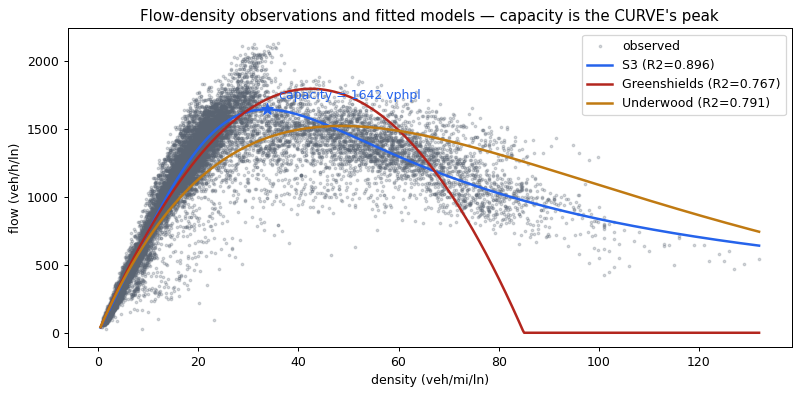

In [4]:
kk = np.linspace(0.5, max(np.nanmax(k), 120), 500)
plt.figure(figsize=(9, 4.5))
plt.scatter(k, q, s=4, alpha=0.25, color="#5a6472", label="observed")
colors = {"S3": "#2563eb", "Greenshields": "#b3261e", "Newell": "#2f9e5e", "Underwood": "#c07a12"}
for name, f in fits.items():
    if f["params"] is None:
        continue
    _, qq = MODELS[name]["fn"](kk, *f["params"])
    plt.plot(kk, qq, lw=2, color=colors[name], label=f"{name} (R2={f['r_squared']:.3f})")
    if name == "S3":
        i = int(np.nanargmax(qq))
        plt.scatter([kk[i]], [qq[i]], s=90, marker="*", color=colors[name], zorder=5)
        plt.annotate(f"capacity = {qq[i]:.0f} vphpl", (kk[i], qq[i]),
                     textcoords="offset points", xytext=(10, 8), color=colors[name])
plt.xlabel("density (veh/mi/ln)"); plt.ylabel("flow (veh/h/ln)")
plt.title("Flow-density observations and fitted models — capacity is the CURVE's peak")
plt.legend(); plt.tight_layout(); plt.show()

## What to notice

- **Model choice changes capacity.** The S3 form usually wins on freeway
  data (it did in the 16-model tournament: RMSE 173.2), but *check R² —
  don't assume*.
- The Huber loss keeps single bad detectors (stuck values, incidents) from
  dragging the fit.
- The congested branch (right of the peak) is thin — most 5-min samples are
  uncongested. That's why episode extraction (notebook 02) matters: it finds
  the minutes that carry the physics.

### Exercises
1. `list(MODELS)` shows every registered form — fit two more and compare.
2. Delete the congested branch (`mask = k < 40`) and re-fit: what happens
   to capacity, and why is that dangerous?
3. Reproduce the full paper tournament: `python ../benchmarks/fd_16models/reproduce_fd16.py`.